In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00011
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  378.75392254442204
RUN  2 , total integrated cost =  107.17789653330165
RUN  3 , total integrated cost =  80.99924281627297
RUN  4 , total integrated cost =  41.31835831980414
RUN  5 , total integrated cost =  33.74585110491308
RUN  6 , total integrated cost =  31.335889453624468
RUN  7 , total integrated cost =  28.382708637422652
RUN  8 , total integrated cost =  27.20313389208141
RUN  9 , total integrated cost =  25.889006343516467
RUN  10 , total integrated cost =  25.253391737102014
RUN  11 , total integrated cost =  24.736567731805366
RUN  12 , total integrated cost =  24.42540074819683
RUN  13 , total integrated cost =  24.235836187341864
RUN  14 , total integrated cost =  24.092132513929972
RUN  15 , total integrated cost =  23.987480566164997


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  29 , total integrated cost =  13087.181051796539
Improved over  29  iterations in  2.105714278295636  seconds by  1.4664102903552845  percent.
Problem in initial value trasfer:  Vmean_exc -56.67221476004601 -56.672218155367105
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  146.44490702646624
RUN  2 , total integrated cost =  64.84206143002751
RUN  3 , total integrated cost =  33.12713019756899
RUN  4 , total integrated cost =  27.0857089705155
RUN  5 , total integrated cost =  26.787402333334438
RUN  6 , total integrated cost =  26.477410121629873
RUN  7 , total integrated cost =  26.250081212889995
RUN  8 , total integrated cost =  26.020474398410876
RUN  9 , total integrated cost =  25.803824076272285
RUN  10 , total integrated cost =  25.600797448258017
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  398 , total integrated cost =  18.873462671702992
Improved over  398  iterations in  25.98696813173592  seconds by  99.91248176559448  percent.
Problem in initial value trasfer:  Vmean_exc -56.698388622517946 -56.698388583797666
weight =  11426.190288145854
set cost params:  1.0 0.0 11426.190288145854
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21523.612827182566
Gradient descend method:  None
RUN  1 , total integrated cost =  21275.37969800279
RUN  2 , total integrated cost =  21275.129657198657
RUN  3 , total integrated cost =  21275.08068466283
RUN  4 , total integrated cost =  21274.630044560916
RUN  5 , total integrated cost =  21274.418082731256
RUN  6 , total integrated cost =  21274.365310616886
RUN  7 , total integrated cost =  21274.016081199698
RUN  8 , total integrated cost =  21273.889751413302
RUN  9 , total integrated cost =  21273.84194687087
RUN  10 , total integrated cost =  21273.472459324214
RUN  11 ,

...

Control only changes marginally.
RUN  37 , total integrated cost =  21250.7924513641
Improved over  37  iterations in  2.52533882856369  seconds by  1.2675398782211573  percent.
Problem in initial value trasfer:  Vmean_exc -56.69837838698144 -56.6983787202159
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21069.13235378212
Gradient descend method:  None
RUN  1 , total integrated cost =  1346.147351828742
RUN  2 , total integrated cost =  93.27960582394601
RUN  3 , total integrated cost =  53.10080090627099
RUN  4 , total integrated cost =  47.82231827500932
RUN  5 , total integrated cost =  47.33560229796861
RUN  6 , total integrated cost =  46.84071200776026
RUN  7 , total integrated cost =  46.40516065472825
RUN  8 , total integrated cost =  45.98642358562401
RUN  9 , total integrated cost =  45.650702580371025
RUN  10 , total integrated cost =  45.339045317195435
RUN  11 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  334 , total integrated cost =  34.74542223220435
Improved over  334  iterations in  21.99004451930523  seconds by  99.83508849985478  percent.
Problem in initial value trasfer:  Vmean_exc -56.6973619493864 -56.697361937186216
weight =  6063.858488458332
set cost params:  1.0 0.0 6063.858488458332
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21028.369214528193
Gradient descend method:  None
RUN  1 , total integrated cost =  20791.485130242887
RUN  2 , total integrated cost =  20790.979741068444
RUN  3 , total integrated cost =  20790.876048662238
RUN  4 , total integrated cost =  20789.943314568678
RUN  5 , total integrated cost =  20788.77926297354
RUN  6 , total integrated cost =  20788.704716834593
RUN  7 , total integrated cost =  20785.640323057538
RUN  8 , total integrated cost =  20782.27600595952
RUN  9 , total integrated cost =  20782.22762183035
RUN  10 , total integrated cost =  20781.9593988502
RUN  11 , total 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  45 , total integrated cost =  20758.51767151019
Improved over  45  iterations in  3.149708980694413  seconds by  1.2832737539702634  percent.
Problem in initial value trasfer:  Vmean_exc -56.69734873950046 -56.69734918133451
-------  44 0.47500000000000014 0.5750000000000003
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019489862996
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019489862996
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019489862996
Improved over  1  iterations in  0.15308385528624058  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019489862996
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019489862996
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019489862996
Improve

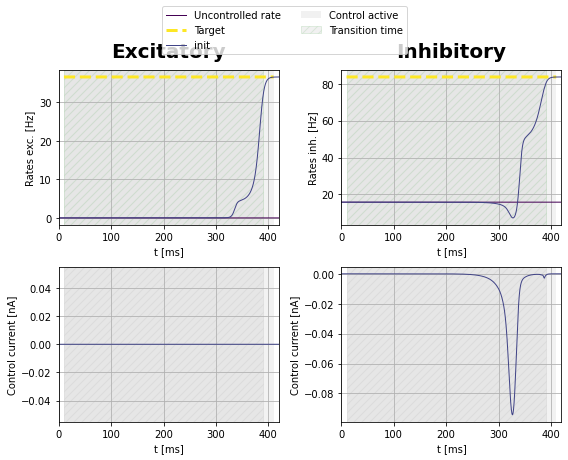

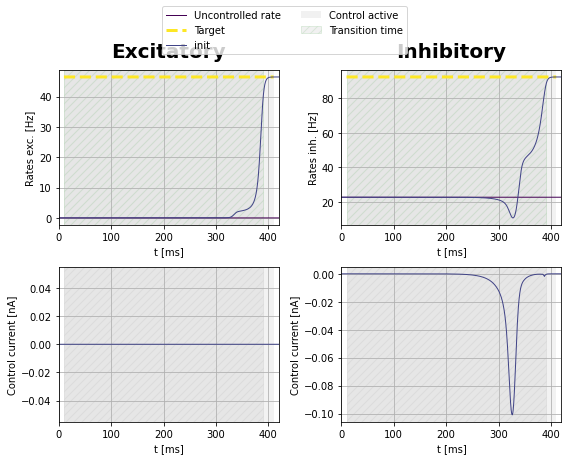

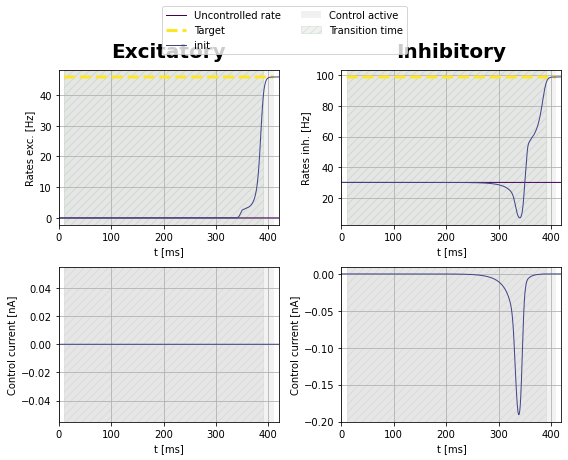

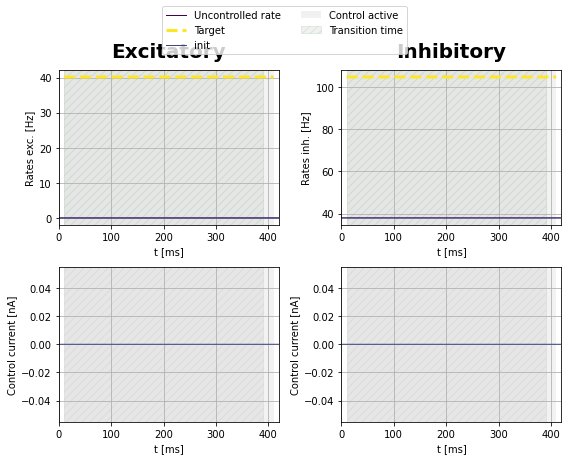

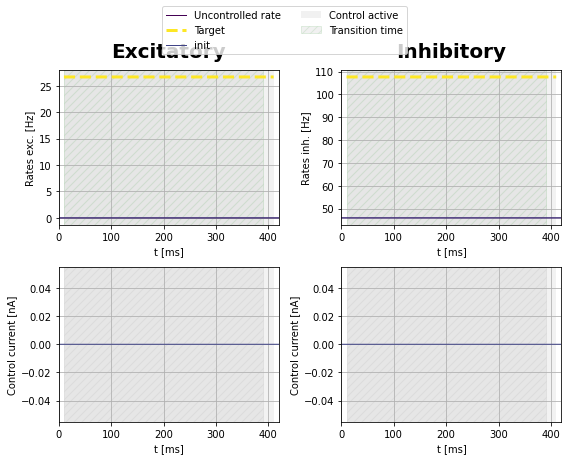

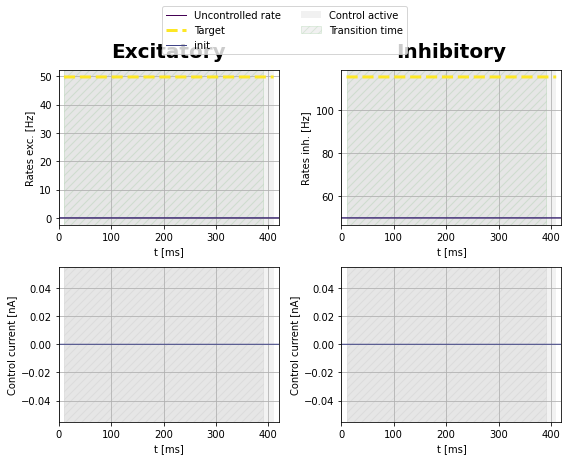

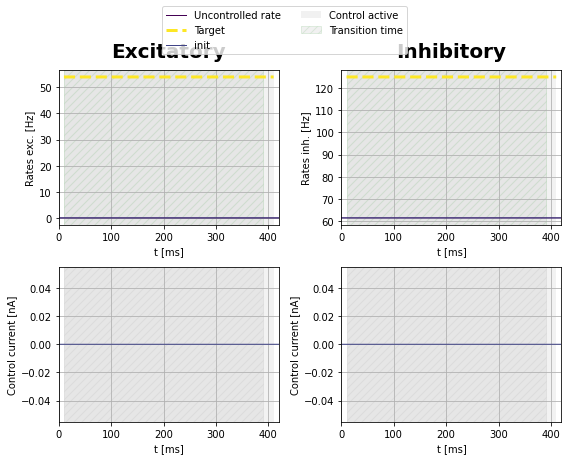

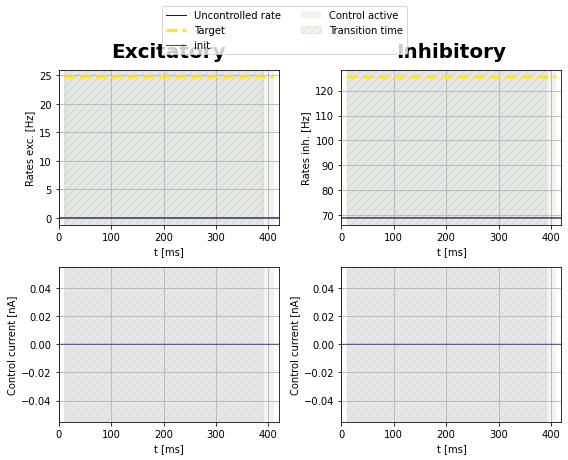

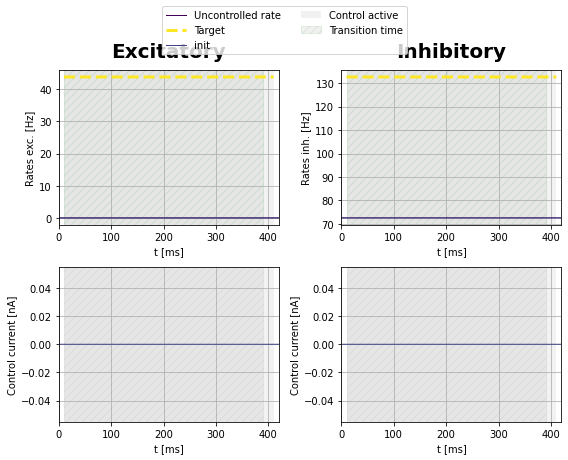

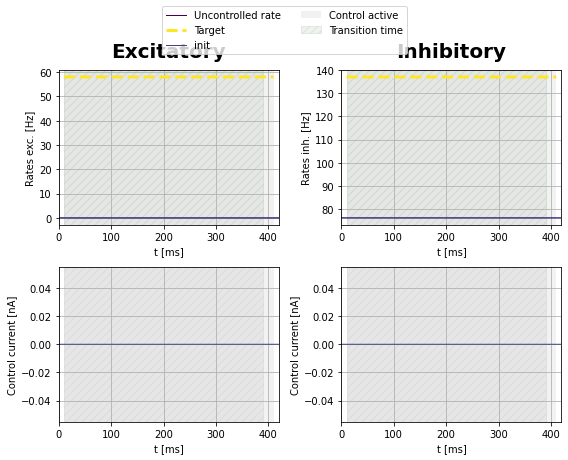

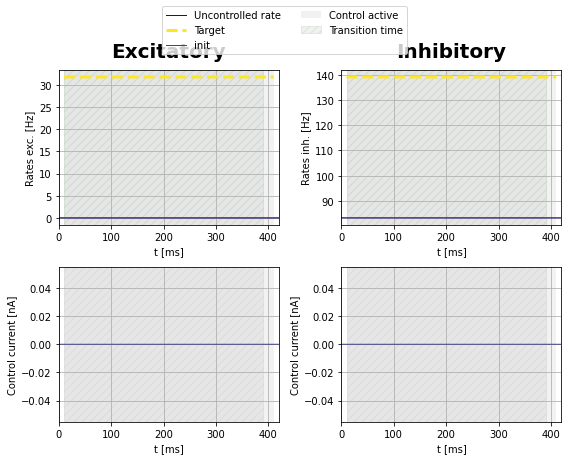

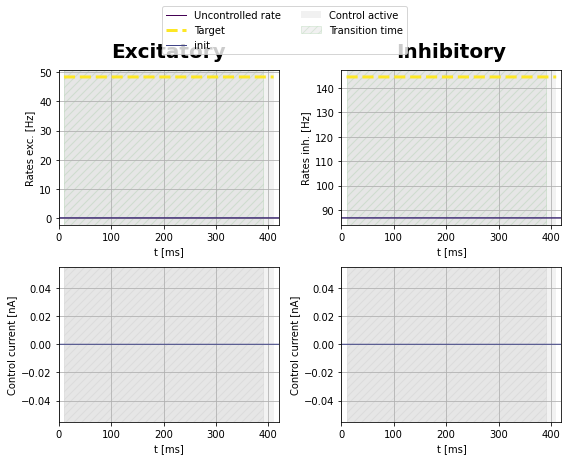

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
found solution for  22
-------

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  158 , total integrated cost =  56.955586547357875
Improved over  158  iterations in  10.52831325121224  seconds by  99.64779573172181  percent.
Problem in initial value trasfer:  Vmean_exc -56.68406205431217 -56.68406201430025
weight =  2833.263682825084
set cost params:  1.0 0.0 2833.263682825084
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16115.98779749293
Gradient descend method:  None
RUN  1 , total integrated cost =  16012.192403500381
RUN  2 , total integrated cost =  16012.147713651313
RUN  3 , total integrated cost =  16012.041217106904
RUN  4 , total integrated cost =  16011.80745063065
RUN  5 , total integrated cost =  16011.774068658868
RUN  6 , total integrated cost =  16011.719707275382
RUN  7 , total integrated cost =  16011.549837297125
RUN  8 , total integrated cost =  16011.508765257118
RUN  9 , total integrated cost =  16011.448406045974
RUN  10 , total integrated cost =  16011.275372802036
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  87 , total integrated cost =  15994.805843006954
Improved over  87  iterations in  6.304417392238975  seconds by  0.7519362511854695  percent.
Problem in initial value trasfer:  Vmean_exc -56.68400234790846 -56.68400396482011
-------  55 0.4250000000000001 0.6250000000000003
[0, 11, 22, 33] []
closest index  33
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7147.081649510289
Gradient descend method:  None
RUN  1 , total integrated cost =  7113.120064213254
RUN  2 , total integrated cost =  99.79367301789463
RUN  3 , total integrated cost =  96.35271926490826
RUN  4 , total integrated cost =  95.86497536085146
RUN  5 , total integrated cost =  95.21055370396618
RUN  6 , total integrated cost =  94.60742409875509
RUN  7 , total integrated cost =  93.7016278666801
RUN  8 , total integrated cost =  93.32578480339784
RUN  9 , total integrated cost =  92.84286630150052
RUN  10 

...

Control only changes marginally.
RUN  580 , total integrated cost =  6119.137860430727
Improved over  580  iterations in  37.40484423190355  seconds by  0.025457212564347742  percent.
Problem in initial value trasfer:  Vmean_exc -56.625463622125366 -56.625464164322366
-------  110 0.5000000000000002 0.8000000000000005
[0, 11, 22, 33, 77] []
closest index  77
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19324.550455670425
Gradient descend method:  None
RUN  1 , total integrated cost =  19227.64614947694
RUN  2 , total integrated cost =  110.95219394175555
RUN  3 , total integrated cost =  107.04593863382243
RUN  4 , total integrated cost =  106.67972724597173
RUN  5 , total integrated cost =  106.66675726990417
RUN  6 , total integrated cost =  106.66635999028038
RUN  7 , total integrated cost =  106.66635800882985
RUN  8 , total integrated cost =  106.66635571870968
RUN  9 , total integrated cost =  106.666

RUN  9 , total integrated cost =  81.35664787811399
RUN  10 , total integrated cost =  81.35656803252957
RUN  11 , total integrated cost =  81.35651668103985
RUN  12 , total integrated cost =  81.35648053816124
RUN  13 , total integrated cost =  81.35645463793036
RUN  14 , total integrated cost =  81.35534442328314
RUN  15 , total integrated cost =  81.35501899487802
RUN  16 , total integrated cost =  81.35501141072484
RUN  17 , total integrated cost =  81.35500516336248
RUN  18 , total integrated cost =  81.35500005763994
RUN  19 , total integrated cost =  81.354995137351
RUN  20 , total integrated cost =  81.35499133323275
RUN  30 , total integrated cost =  80.68683048013965
RUN  40 , total integrated cost =  76.27471133376721
RUN  50 , total integrated cost =  75.63202036110509
RUN  60 , total integrated cost =  75.61162984052558
RUN  70 , total integrated cost =  74.45435989063982
RUN  80 , total integrated cost =  74.45434183423994
RUN  90 , total integrated cost =  74.45432578901

RUN  100 , total integrated cost =  142.9608412560952
RUN  110 , total integrated cost =  142.9608406295122
RUN  120 , total integrated cost =  142.9608398032746
RUN  130 , total integrated cost =  142.96083901016974
RUN  140 , total integrated cost =  142.9608375917583
RUN  150 , total integrated cost =  142.96083706240336
RUN  160 , total integrated cost =  142.96083636679666
RUN  170 , total integrated cost =  142.9608349508114
RUN  180 , total integrated cost =  142.96083442156385
RUN  190 , total integrated cost =  142.96083300466623
RUN  200 , total integrated cost =  142.9608315668647
RUN  300 , total integrated cost =  142.96081162649838
RUN  400 , total integrated cost =  142.96078262529392
RUN  500 , total integrated cost =  142.96076963220895
RUN  600 , total integrated cost =  142.96075747979359
RUN  700 , total integrated cost =  142.96073891782433
RUN  800 , total integrated cost =  142.96070771094986
RUN  900 , total integrated cost =  142.96064946971237
RUN  1000 , tota

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  10117.551799298511
RUN  11 , total integrated cost =  10117.551799298506
RUN  12 , total integrated cost =  10117.551799298506
Control only changes marginally.
RUN  12 , total integrated cost =  10117.551799298506
Improved over  12  iterations in  1.1764699667692184  seconds by  0.00016289324229035174  percent.
Problem in initial value trasfer:  Vmean_exc -56.65232265681818 -56.65232276603228
-------  143 0.5250000000000001 0.9000000000000006
[0, 11, 22, 33, 77] []
closest index  77
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23529.2209570852
Gradient descend method:  None
RUN  1 , total integrated cost =  23432.316655604616
RUN  2 , total integrated cost =  123.45316727712883
RUN  3 , total integrated cost =  122.57422106609201
RUN  4 , total integrated cost =  122.55896161723395
RUN  5 , total integrated cost =  122.55862588610006
RUN  6 , total integrated cost =  122.5

In [ ]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  7572.709503167477
set cost params:  1.0 0.0 7572.709503167477
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13309.254150721908
Gradient descend method:  None
RUN  1 , total integrated cost =  13309.252596203427
RUN  2 , total integrated cost =  13309.252581604971
RUN  3 , total integrated cost =  13309.252581186429
RUN  4 , total integrated cost =  13309.252581166595
RUN  5 , total integrated cost =  13309.25258116586
RUN  6 , total integrated cost =  13309.252581165812
RUN  7 , total integrated cost =  13309.252581165792
RUN  8 , total integrated cost =  13309.252581165778


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  13309.252581165778
Control only changes marginally.
RUN  9 , total integrated cost =  13309.252581165778
Improved over  9  iterations in  1.3931387774646282  seconds by  1.1792968351187483e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.67221385172363 -56.67221726922477
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  11594.229838399122
set cost params:  1.0 0.0 11594.229838399122
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21562.791767130373
Gradient descend method:  None
RUN  1 , total integrated cost =  21562.78882301961
RUN  2 , total integrated cost =  21562.788787599893
RUN  3 , total integrated cost =  21562.78878745518
RUN  4 , total integrated cost =  21562.7887874536
RUN  5 , total integrated cost =  21562.788787453577
RUN  6 , total integrated cost =  21562.78878745357


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  21562.78878745357
Control only changes marginally.
RUN  7 , total integrated cost =  21562.78878745357
Improved over  7  iterations in  1.244659136980772  seconds by  1.3818603989079747e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.69837831304163 -56.69837864888184
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  6153.5934584374
set cost params:  1.0 0.0 6153.5934584374
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21065.12673891441
Gradient descend method:  None
RUN  1 , total integrated cost =  21065.123962249618
RUN  2 , total integrated cost =  21065.123945265354
RUN  3 , total integrated cost =  21065.12394524928
RUN  4 , total integrated cost =  21065.123945249226
RUN  5 , total integrated cost =  21065.123945249215
RUN  6 , total integrated cost =  21065.12394524921


...

RUN  17 , total integrated cost =  29119.2230606519
RUN  18 , total integrated cost =  29119.223057385585
RUN  19 , total integrated cost =  29119.223057186937
RUN  20 , total integrated cost =  29119.22305698689
RUN  30 , total integrated cost =  29119.222989604943
RUN  40 , total integrated cost =  29119.22287366074
RUN  50 , total integrated cost =  29119.222810349514
RUN  60 , total integrated cost =  29119.2227602347
RUN  70 , total integrated cost =  29119.222710122987
RUN  80 , total integrated cost =  29119.22266001267
RUN  90 , total integrated cost =  29119.22260990336
RUN  100 , total integrated cost =  29119.222557118956
RUN  110 , total integrated cost =  29119.22248325154
RUN  120 , total integrated cost =  29119.222362417477
RUN  130 , total integrated cost =  29119.222312380487
RUN  140 , total integrated cost =  29119.22226226899
RUN  150 , total integrated cost =  29119.22221215955
RUN  160 , total integrated cost =  29119.22216205112
RUN  170 , total integrated cost 

RUN  30 , total integrated cost =  23419.382168361
RUN  40 , total integrated cost =  23419.382130376565
RUN  50 , total integrated cost =  23419.382058336905
RUN  60 , total integrated cost =  23419.3820505917
RUN  70 , total integrated cost =  23419.380654232657
RUN  80 , total integrated cost =  23419.380632064618
RUN  90 , total integrated cost =  23419.380560029338
RUN  100 , total integrated cost =  23419.38053620761
RUN  110 , total integrated cost =  23419.380058274855
RUN  120 , total integrated cost =  23419.37913583726
RUN  130 , total integrated cost =  23419.377757839313
RUN  140 , total integrated cost =  23419.376315291014
RUN  150 , total integrated cost =  23419.376301689696
RUN  160 , total integrated cost =  23419.374912772328
RUN  170 , total integrated cost =  23419.373536576593
RUN  180 , total integrated cost =  23419.37352761782
RUN  190 , total integrated cost =  23419.371973733792
RUN  200 , total integrated cost =  23419.370422844666
RUN  300 , total integrat

RUN  17 , total integrated cost =  19215.770309601212
RUN  18 , total integrated cost =  19215.770309450694
RUN  19 , total integrated cost =  19215.770305959628
RUN  20 , total integrated cost =  19215.770304997248
RUN  30 , total integrated cost =  19215.770298095096
RUN  40 , total integrated cost =  19215.77026727284
RUN  50 , total integrated cost =  19215.77026042835
RUN  60 , total integrated cost =  19215.770256556738
RUN  70 , total integrated cost =  19215.770250153786
RUN  80 , total integrated cost =  19215.77024330918
RUN  90 , total integrated cost =  19215.770239396938
RUN  100 , total integrated cost =  19215.770232879368
RUN  110 , total integrated cost =  19215.770226034932
RUN  120 , total integrated cost =  19215.77022216352
RUN  130 , total integrated cost =  19215.770215760425
RUN  140 , total integrated cost =  19215.77020891587
RUN  150 , total integrated cost =  19215.770205003686
RUN  160 , total integrated cost =  19215.770198486105
RUN  170 , total integrate

RUN  9 , total integrated cost =  29119.223108071372
RUN  10 , total integrated cost =  29119.223091148167
RUN  11 , total integrated cost =  29119.223090827316
RUN  12 , total integrated cost =  29119.223090698553
RUN  13 , total integrated cost =  29119.223090584586
RUN  14 , total integrated cost =  29119.223089561146
RUN  15 , total integrated cost =  29119.223052029956
RUN  16 , total integrated cost =  29119.22303510579
RUN  17 , total integrated cost =  29119.22303478488
RUN  18 , total integrated cost =  29119.223034656134
RUN  19 , total integrated cost =  29119.223034542167
RUN  20 , total integrated cost =  29119.22303351875
RUN  30 , total integrated cost =  29119.222922571607
RUN  40 , total integrated cost =  29119.2228109372
RUN  50 , total integrated cost =  29119.222753308317
RUN  60 , total integrated cost =  29119.2226423622
RUN  70 , total integrated cost =  29119.222530728795
RUN  80 , total integrated cost =  29119.222473100544
RUN  90 , total integrated cost =  2

RUN  13 , total integrated cost =  23419.383603062706
RUN  14 , total integrated cost =  23419.383602936436
RUN  15 , total integrated cost =  23419.38359830727
RUN  16 , total integrated cost =  23419.383596584674
RUN  17 , total integrated cost =  23419.383596532323
RUN  18 , total integrated cost =  23419.383596517382
RUN  19 , total integrated cost =  23419.38359649931
RUN  20 , total integrated cost =  23419.383596392818
RUN  30 , total integrated cost =  23419.383580859674
RUN  40 , total integrated cost =  23419.383565259068
RUN  50 , total integrated cost =  23419.38355849035
RUN  60 , total integrated cost =  23419.383542980653
RUN  70 , total integrated cost =  23419.383529915587
RUN  80 , total integrated cost =  23419.38352059901
RUN  90 , total integrated cost =  23419.383507625294
RUN  100 , total integrated cost =  23419.38349203171
RUN  110 , total integrated cost =  23419.383485277824
RUN  120 , total integrated cost =  23419.383469744815
RUN  130 , total integrated co

In [ ]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [ ]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [ ]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

In [ ]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

In [ ]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [ ]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

In [ ]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

In [ ]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [ ]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [ ]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

In [ ]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

In [ ]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)